In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data

--2026-03-12 13:05:04--  https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘auto-mpg.data’

auto-mpg.data           [ <=>                ]  29.58K   179KB/s    in 0.2s    

2026-03-12 13:05:06 (179 KB/s) - ‘auto-mpg.data’ saved [30286]



In [3]:
cols = [
    "mpg", "cylinders", "displacement", "horsepower",
    "weight", "acceleration", "model_year", "origin"
]

df = pd.read_csv(
    "auto-mpg.data",
    sep=r"\s+",
    header=None,
    engine="python",
    usecols=list(range(8)),
    names=cols
)

df = df.replace("?", np.nan)

for c in df.columns:
    df[c] = pd.to_numeric(df[c], errors="coerce")

print(df.shape)
display(df.head())
print(df.isna().sum())

(398, 8)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,18.0,8,307.0,130.0,3504.0,12.0,70,1
1,15.0,8,350.0,165.0,3693.0,11.5,70,1
2,18.0,8,318.0,150.0,3436.0,11.0,70,1
3,16.0,8,304.0,150.0,3433.0,12.0,70,1
4,17.0,8,302.0,140.0,3449.0,10.5,70,1


mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
dtype: int64


In [4]:
X = df.drop(columns=["mpg"])
y = df["mpg"]

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=42
)

imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_train = imputer.fit_transform(X_train)
X_val = imputer.transform(X_val)
X_test = imputer.transform(X_test)

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

y_train = y_train.to_numpy().reshape(-1, 1)
y_val = y_val.to_numpy().reshape(-1, 1)
y_test = y_test.to_numpy().reshape(-1, 1)

print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (238, 7) (238, 1)
Val: (80, 7) (80, 1)
Test: (80, 7) (80, 1)


In [6]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)

y_train_t = torch.tensor(y_train, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

In [7]:
model = nn.Sequential(
    nn.Linear(X_train.shape[1], 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 1)
)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

print(model)

Sequential(
  (0): Linear(in_features=7, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=1, bias=True)
)


In [8]:
num_epochs = 300

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    pred_train = model(X_train_t)
    loss_train = criterion(pred_train, y_train_t)

    optimizer.zero_grad()
    loss_train.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        pred_val = model(X_val_t)
        loss_val = criterion(pred_val, y_val_t)

    train_losses.append(loss_train.item())
    val_losses.append(loss_val.item())

    if epoch % 50 == 0:
        print(f"Epoch {epoch}: train loss = {loss_train.item():.4f}, val loss = {loss_val.item():.4f}")

Epoch 0: train loss = 599.7487, val loss = 680.0212
Epoch 50: train loss = 439.1477, val loss = 496.4378
Epoch 100: train loss = 81.6183, val loss = 94.6485
Epoch 150: train loss = 33.7629, val loss = 41.9129
Epoch 200: train loss = 21.2712, val loss = 29.4001
Epoch 250: train loss = 16.3370, val loss = 24.0087


In [9]:
model.eval()

with torch.no_grad():
    y_val_pred = model(X_val_t).numpy()
    y_test_pred = model(X_test_t).numpy()

val_mse = mean_squared_error(y_val, y_val_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

val_rmse = np.sqrt(val_mse)
test_rmse = np.sqrt(test_mse)

val_mae = mean_absolute_error(y_val, y_val_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

val_r2 = r2_score(y_val, y_val_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("Validation results:")
print("MSE =", val_mse)
print("RMSE =", val_rmse)
print("MAE =", val_mae)
print("R2 =", val_r2)

print("\nTest results:")
print("MSE =", test_mse)
print("RMSE =", test_rmse)
print("MAE =", test_mae)
print("R2 =", test_r2)

Validation results:
MSE = 20.958672700997024
RMSE = 4.57806429629347
MAE = 3.5412748217582704
R2 = 0.717869563059494

Test results:
MSE = 13.232183974618527
RMSE = 3.637606902156764
MAE = 2.876281905174255
R2 = 0.753895123952316


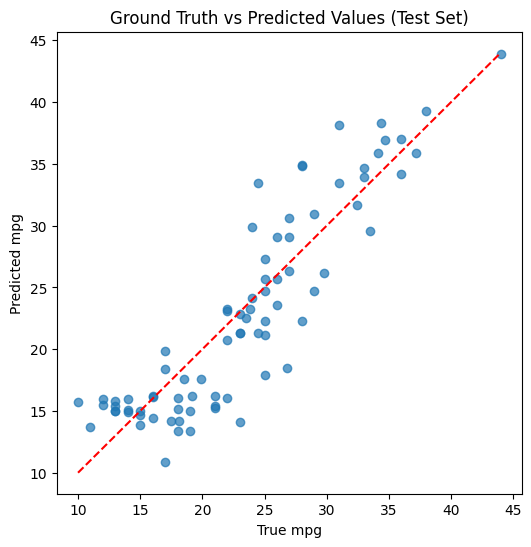

In [10]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_test_pred, alpha=0.7)
plt.xlabel("True mpg")
plt.ylabel("Predicted mpg")
plt.title("Ground Truth vs Predicted Values (Test Set)")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

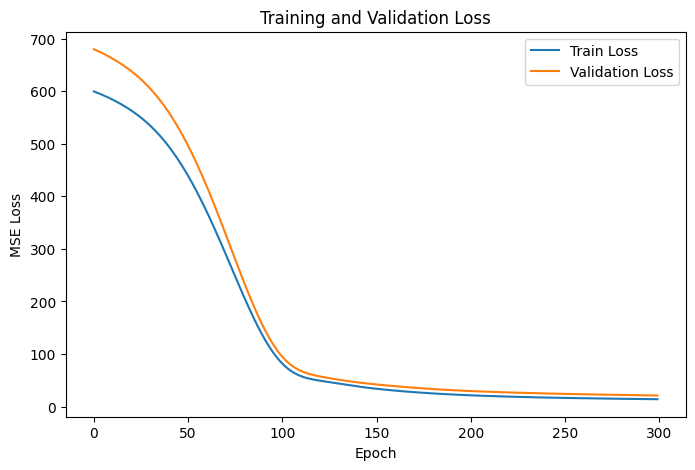

In [11]:
plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()